# Book-of-Life Pipeline for NLSY79 — Simplified

Simplified adaptation of `bol_pipeline.ipynb`, skipping the `bolt/` repository.

1. Reshape the wide RNUM-headed CSV into long person and year tables.
2. Inspect Descriptive Statistics.
3. Render Books of Life directly from the reshaped DataFrames.
4. Make predictions with LLM (zero-shot, 10-shot) plus a naive & logistic-regression baseline.

## 1 Setup

### 1.1 Data loading

In [1]:
# Imports
import asyncio, json, os, sys, time, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")

# Define paths
REPO = Path(".").resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO)
sys.path.insert(0, str(REPO))

# Load .env so NLSY79_EXTRACT_PREFIX (and later API keys) are available.
env_path = REPO / ".env"
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

PREFIX = os.environ.get("NLSY79_EXTRACT_PREFIX", "data")
RAW_CSV = REPO / f"data/raw/{PREFIX}.csv"
RAW_CDB = REPO / f"data/raw/{PREFIX}.cdb"
OUT_DIR = REPO / "data/processed"
BOOKS_JSON = OUT_DIR / "books.json"
PREDICTIONS_CSV = OUT_DIR / "predictions.csv"

print(f"REPO: {REPO}")


REPO: /home/mnov/projects/microtasks/lifecourse_seminar/bolt_nlsy79_starter


### 1.2 Choice of outcome

- `TARGET_RNUM` selects the raw column to predict.
- `OUTCOME_YEAR_MODE` controls how the input window is bounded relative to the outcome:
  - `"age"` : per-respondent window based on age, adhering to `survey_year < birth_year + OUTCOME_AGE`. Use for outcomes anchored to an age (e.g., here: SF-12 health scale at 40).
  - `"survey_year"`: calendar-year cutoff to predict the same year (at different respondent ages) with `drop_year_below` / `drop_year_above`.
- `BLOCK_QNAME_PREFIXES` deletes unused modules from the raw data to prevent target leakage.
- `BLOCK_RNUMS` blocks specific RNUMs.

| Target example | What to block |
|---|---|
| H40-SF12-2 (SRH at age 40) | `("h40_",)` |
| Wage in 2010 | `()` |
| Marriage timing | `("marstat_",)` |

In [2]:
TARGET_RNUM = "H0003400"
OUTCOME_YEAR_MODE = "age"
OUTCOME_AGE = 40

# We block other measures similar to the target variable 
BLOCK_QNAME_PREFIXES = ("h40_","cesd_score_20_item")
# The 1981 birth-year/month re-recoding (R0410100, R0410300) is blocked by default: the 1979 birth info is a strict superset, but 111 cases disagree on year (more on month) — we use the 1979 source.
# We also block the cesd_score_20_item scale (R3896810) in favor of the cesd_score_7_item scale, which is measured twice (1992, 1994)
BLOCK_RNUMS = ("R0410100", "R0410300", "R3896810")


### 1.3 Reshape

Writes to `data/processed/`:
- `nlsy79_person.csv` — one row per respondent. **Loaded by BOLT.**
- `nlsy79_year_full.csv` — every (caseid, survey_year) observation; no dedup, for inspection / baselines.
- `nlsy79_year.csv` — sparse variant with spell logic (cell blanked if equal to prior non-null). **Loaded by BOLT.**
- `targets.csv` — caseid + target (+ outcome_age + outcome_calendar_year in age mode).
- `variable_index.csv` — audit + readable_name / sentence_template / transformation columns merged from variable_metadata.csv.

`apply_tolerance_dedup` extends sparse dedup with a per-qname relative-change threshold; default `{}` = off. Comment it out for a clean one-liner removal.

In [ ]:
from reshape_nlsy79 import reshape_nlsy79, apply_tolerance_dedup

# NLSY79 missing-data sentinels (shown in the stats below):
#   -1 refusal   -2 dk (don't know)   -3 invskip (questionnaire flow bug)
#   -4 vskip (skipped by design — not applicable)   -5 niv (non-interview)

paths = reshape_nlsy79(
    raw_csv_path=RAW_CSV,
    cdb_path=RAW_CDB,
    out_dir=OUT_DIR,
    target_rnum=TARGET_RNUM,
    block_qname_prefixes=BLOCK_QNAME_PREFIXES,
    block_rnums=BLOCK_RNUMS,
    outcome_year_mode=OUTCOME_YEAR_MODE,
    outcome_age=OUTCOME_AGE,
    # drop_year_below: 1979,
    # drop_year_above: 2026
)

person = pd.read_csv(paths["person"])
year_full = pd.read_csv(paths["year_full"])
year = pd.read_csv(paths["year"])
targets = pd.read_csv(paths["targets"])
idx = pd.read_csv(paths["variable_index"]) # variable_index

# Optional tolerance dedup; example: {"q11_9": 0.02} suppresses weight readings within 2% of previous.
# year = apply_tolerance_dedup(year, tolerances={})

print(f"persons:     {len(person):>7,} rows × {len(person.columns):>2} cols")
print(f"year_full:   {len(year_full):>7,} rows × {len(year_full.columns):>2} cols  (non-null cells: {year_full.notna().sum().sum():,})")
print(f"year: {len(year):>7,} rows × {len(year.columns):>2} cols  (non-null cells: {year.notna().sum().sum():,})")
print(f"targets:     {len(targets):>7,} rows × {len(targets.columns):>2} cols")
print(f"\nVariable routing:\n{idx['table'].value_counts().to_string()}")

Wrote data/helpers/value_labels.csv: 952 rows, 27 qnames

=== Person variables ===
  birth_month                 N=12,686  min=1  p25=4  med=7  p75=9  max=12  missing=[—]
  birth_year                  N=12,686  min=1957  p25=1958  med=1960  p75=1962  max=1964  missing=[—]
  mother_education            N=11,878  unique=21  missing=[vskip:27, invskip:251, dk:527, refusal:3]
  father_education            N=10,880  unique=21  missing=[vskip:230, invskip:423, dk:1150, refusal:3]
  sample_id                   N=12,686  unique=20  missing=[—]
  race                        N=12,686  unique=3  missing=[—]
  sex                         N=12,686  unique=2  missing=[—]
  outcome_age                 N=12,686  min=40  p25=40  med=40  p75=40  max=40  missing=[—]
  outcome_calendar_year       N=12,686  min=1997  p25=1998  med=2000  p75=2002  max=2004  missing=[—]

=== Year variables ===
  cesd_7                      N=16,314  min=0  p25=1  med=3  p75=6  max=21  missing=[niv:7465, vskip:2, invskip:69, 

## 2 Descriptive statistics

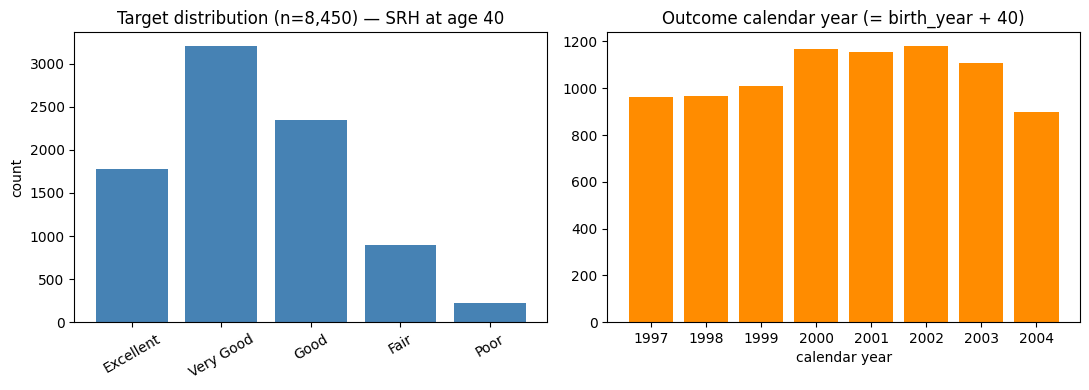

Year-table (full) summary:
                            count    mean    std    min    25%    50%    75%    max  %missing
cesd_7                    17806.0    3.99   4.06    0.0    1.0    3.0    6.0   21.0     90.19
household_size           181545.0    3.42   1.96    1.0    2.0    3.0    4.0   15.0      0.00
height_cm                 12143.0  170.20  10.31  122.0  163.0  170.0  178.0  211.0     93.31
highest_grade_completed  181186.0   12.29   2.35    0.0   12.0   12.0   13.0   20.0      0.20
weight_kg                111599.0   72.38  17.00   21.0   60.0   70.0   82.0  452.0     38.53
weeks_worked             175614.0   33.49  21.00    0.0   12.0   45.0   52.0   57.0      3.27


In [4]:
SRH_NAMES = {1: "Excellent", 2: "Very Good", 3: "Good", 4: "Fair", 5: "Poor"}

# Left plot - Target distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = targets["target"].value_counts().sort_index()
axes[0].bar([SRH_NAMES.get(int(k), str(k)) for k in counts.index], counts.values, color="steelblue")
axes[0].set_title(f"Target distribution (n={len(targets):,}) — SRH at age 40")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=30)

# Right plot - outcome calendar year
oc = targets["outcome_calendar_year"].dropna().astype(int).value_counts().sort_index()
axes[1].bar(oc.index, oc.values, color="darkorange")
axes[1].set_title("Outcome calendar year (= birth_year + 40)")
axes[1].set_xlabel("calendar year")
plt.tight_layout(); plt.show()

summary = (year_full
           .drop(columns=["caseid", "survey_year"])
           .describe(percentiles=[.25, .5, .75]).T)
summary["%missing"] = (1 - year_full.drop(columns=["caseid","survey_year"]).count() / len(year_full)) * 100
print("Year-table (full) summary:")
print(summary.round(2).to_string())

# Note - height is in foot & inches; further transformations may be needed to interpret this meaningfully.

### 1.4 Train / test split

5% test set (~423 cases) to keep API costs low. Below we also compare train vs test target distribution.

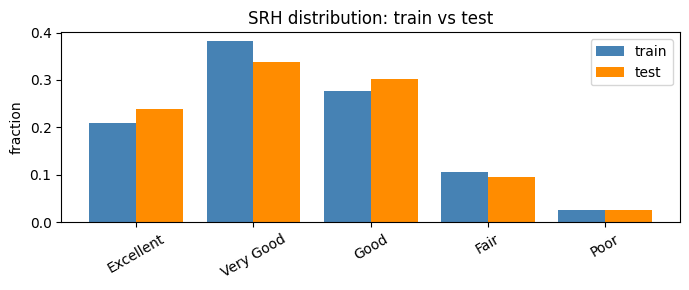

train=8,027  test=423


In [5]:
# Ideally we'd only look at validation, not at test

SEED = 260409
rng = np.random.default_rng(SEED)
caseids = targets["caseid"].astype(int).to_numpy()
perm = rng.permutation(len(caseids))
n_train = int(0.95 * len(caseids))
train_ids = set(caseids[perm[:n_train]])
test_ids  = set(caseids[perm[n_train:]])

train_dist = targets[targets["caseid"].isin(train_ids)]["target"].value_counts(normalize=True).sort_index()
test_dist  = targets[targets["caseid"].isin(test_ids)]["target"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(5) + 1
w = 0.4
ax.bar(x - w/2, [train_dist.get(i, 0) for i in x], width=w, label="train", color="steelblue")
ax.bar(x + w/2, [test_dist.get(i, 0)  for i in x], width=w, label="test",  color="darkorange")
ax.set_xticks(x); ax.set_xticklabels([SRH_NAMES[i] for i in x], rotation=30)
ax.set_ylabel("fraction"); ax.set_title("SRH distribution: train vs test")
ax.legend(); plt.tight_layout(); plt.show()

print(f"train={len(train_ids):,}  test={len(test_ids):,}")

## 3 Generate Books of Life (pandas)

We render each respondent's Book of Life directly from `person` and `year`
(already produced by `reshape_nlsy79`). Categorical labels and unit
transformations are baked in at reshape time, so the renderer is trivial:
load sentence templates, then walk the rows.

`books.json` is saved for human inspection in the same format as the
bolt-based pipeline.

In [ ]:
import csv

# Sentence templates: {readable_name: "born in {value}"} — sourced from
# data/variable_metadata.csv (the user-curated overlay merged into
# variable_index.csv at reshape time).
templates = {}
with open(REPO / "data/variable_metadata.csv", newline="") as f:
    for r in csv.DictReader(f):
        name = (r.get("readable_name") or "").strip()
        tpl = (r.get("sentence_template") or "").strip()
        if name and tpl:
            templates[name] = tpl

PERSON_SKIP = {"caseid", "outcome_age", "outcome_calendar_year"}
YEAR_SKIP = {"caseid", "survey_year"}


def _render_attrs(row, skip):
    """Return list of formatted phrases for the non-missing, non-skipped attributes."""
    parts = []
    for k, v in row.items():
        if k in skip or pd.isna(v):
            continue
        tpl = templates.get(k)
        # Template substitution if defined, else "{label} {value}" fallback.
        parts.append(tpl.format(value=v) if tpl else f"{k.replace('_', ' ')} {v}")
    return parts


def book_for(cid):
    """Render one respondent's Book of Life as a string."""
    p_rows = person[person["caseid"] == cid]
    if not len(p_rows):
        return ""
    p = p_rows.iloc[0]
    body = "This person — " + "; ".join(_render_attrs(p, PERSON_SKIP)) + "."
    if pd.notna(p.get("outcome_age")) and pd.notna(p.get("outcome_calendar_year")):
        body += f" The prediction target is measured at age {p['outcome_age']} ({p['outcome_calendar_year']})."
    y_rows = year[year["caseid"] == cid].sort_values("survey_year")
    for _, y in y_rows.iterrows():
        parts = _render_attrs(y, YEAR_SKIP)
        if parts:
            body += f"\nIn {int(y['survey_year'])}: " + "; ".join(parts) + "."
    return body


t0 = time.time()
all_books = {int(cid): book_for(int(cid)) for cid in targets["caseid"]}
print(f"Generated {len(all_books)} BoLs in {time.time()-t0:.1f}s")

test_books = {cid: all_books[cid] for cid in sorted(test_ids) if cid in all_books}
train_books = {cid: all_books[cid] for cid in sorted(train_ids) if cid in all_books}

# Persist for inspection (same shape as bolt's save_books_to_json).
import datetime
now = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds")
payload = {str(cid): {"text": text, "generated_at": now} for cid, text in all_books.items()}
BOOKS_JSON.write_text(json.dumps(payload, indent=2, sort_keys=True))
print(f"Saved {len(all_books)} books → {BOOKS_JSON.relative_to(REPO)}")

print(f"\navg test book length: {int(np.mean([len(b) for b in test_books.values()]))} chars\n")
print("=== SAMPLE ===")
print(list(test_books.values())[0][:1500])


Generated 8450 BoLs in 8.6s
Saved 8450 books → data/processed/books.json

avg test book length: 1202 chars

=== SAMPLE ===
This person — birth month was 3; born in 1958; mother completed 12TH GRADE; father completed 4TH YR COL; belongs to sample CROSS MALE WHITE; race: NON-BLACK, NON-HISPANIC; sex: MALE. The prediction target is measured at age 40 (1998).

In 1979: lived in a household of 1.0; highest grade completed was 12.0; marital status: NEVER MARRIED; worked 29.0 weeks.

In 1980: lived in a household of 2.0; marital status: MARRIED; worked 31.0 weeks.

In 1981: was 175.0 cm in height; weighed 70.0 kg; worked 52.0 weeks.

In 1982: weighed 66.0 kg.

In 1983: lived in a household of 3.0.

In 1984: highest grade completed was 13.0.

In 1985: weighed 70.0 kg.

In 1986: lived in a household of 4.0; weighed 73.0 kg.

In 1988: weighed 75.0 kg.

In 1989: weighed 72.0 kg.

In 1990: lived in a household of 5.0; weighed 75.0 kg.

In 1992: CESD-7 depression score: 1.0; lived in a household of

Note: Descriptions are obviously quite descriptive, and not all codes are very interpretable. One could also try to already summarize / portray that block differently.

## 4 Prediction

### 4.1 LLM endpoint (OpenAI or Azure AI Foundry)

Azure is preferred when `AZURE_OPENAI_ENDPOINT` is set in `.env`. Required env vars:

| Backend | Env vars |
|---|---|
| OpenAI | `OPENAI_API_KEY` |
| Azure AI Foundry | `AZURE_OPENAI_API_KEY`, `AZURE_OPENAI_ENDPOINT` (Foundry project endpoint), `AZURE_OPENAI_DEPLOYMENT` |

Foundry uses the OpenAI-compatible v1 API (`<endpoint>/openai/v1`), no `api-version` needed.

**Azure for Students:**
1. Sign up at <https://azure.microsoft.com/en-us/free/students>.
2. Create a Foundry resource in *Germany West Central*.
3. Add a model deployment (e.g. `gpt-oss-120b`) at <https://ai.azure.com/>.

In [ ]:
def _looks_real(v):
    return bool(v) and "<" not in v and "..." not in v

azure_endpoint = os.environ.get("AZURE_OPENAI_ENDPOINT", "")
azure_key      = os.environ.get("AZURE_OPENAI_API_KEY", "")
USE_AZURE = _looks_real(azure_endpoint) and _looks_real(azure_key)

if USE_AZURE:
    # Azure AI Foundry (Models-as-a-Service, e.g. gpt-oss-*) speaks the
    # OpenAI-compatible v1 API: no api-version, just a base_url. The classic
    # AzureOpenAI client + api-version rejects Foundry endpoints.
    from openai import AsyncOpenAI
    aclient = AsyncOpenAI(
        api_key=azure_key,
        base_url=f"{azure_endpoint.rstrip('/')}/openai/v1",
    )
    MODEL = os.environ.get("AZURE_OPENAI_DEPLOYMENT", "gpt-oss-120b")
    print(f"Using Azure Foundry v1 deployment: {MODEL}")
else:
    from openai import AsyncOpenAI
    aclient = AsyncOpenAI()
    MODEL = "gpt-5.4-nano"
    print(f"Using OpenAI model: {MODEL}")

CONCURRENCY = 5
BOL_TRIM = 9999 # Character limit for Books of Life

# Reasoning models (gpt-oss-*, o1, o3, ...) burn tokens on internal reasoning
# before emitting visible output. Setting reasoning_effort="low" keeps the
# reasoning short for this 5-class classification task (~140 tok / 10-shot call).
# Set to None to skip the param (for non-reasoning models).
REASONING_EFFORT = "low"
#MAX_COMPLETION_TOKENS = 300

Using Azure Foundry v1 deployment: gpt-oss-120b


### 4.2 Few-shot exemplars

10 stratified training exemplars (2 per SRH class) are embedded in the **system prompt** so the OpenAI / Azure prompt cache can re-use the prefix across all test calls. The user message is just the test respondent's BoL.

`SRH_LABELS` is loaded from `value_labels.csv` (qname `h40_sf12_2`).

In [8]:
import csv

SRH_LABELS = {}
with open(REPO / "data/helpers/value_labels.csv", newline="") as f:
    for r in csv.DictReader(f):
        if r["qname"] == "h40_sf12_2":
            SRH_LABELS[int(r["code"])] = r["label"].title()
LABEL_TO_INT = {v.lower(): k for k, v in SRH_LABELS.items()}

def parse_srh(text):
    t = (text or "").strip().lower()
    for label, val in LABEL_TO_INT.items():
        if label in t:
            return val
    return None

target_by_caseid = dict(zip(targets["caseid"].astype(int), targets["target"].astype(int)))
train_df = pd.DataFrame({"caseid": list(train_books.keys())})
train_df["target"] = train_df["caseid"].map(target_by_caseid)

exemplars = []
for srh_val in sorted(SRH_LABELS):
    sub = train_df[train_df["target"] == srh_val]
    if not len(sub):
        continue
    for _, r in sub.sample(n=min(2, len(sub)), random_state=SEED).iterrows():
        exemplars.append({"book": train_books[r["caseid"]][:BOL_TRIM], "srh": SRH_LABELS[r["target"]]})

EXEMPLAR_BLOCK = "\n\n".join(
    f"--- Example {i+1} (gold answer: {ex['srh']}) ---\n{ex['book']}"
    for i, ex in enumerate(exemplars)
)

SYSTEM_PROMPT_ZERO = (
    "You are a health prediction model. Given a life history from the US "
    "National Longitudinal Survey of Youth (NLSY79, born 1957-1964), predict "
    "the respondent's self-rated general health at around age 40.\n\n"
    "Answer with EXACTLY one of: Excellent, Very Good, Good, Fair, Poor."
)
SYSTEM_PROMPT_FEW = (
    SYSTEM_PROMPT_ZERO
    + "\n\nBelow you will see 10 example life histories with their gold answers. "
      "Then, in the user turn, you will see one further life history and must make a prediction.\n\n"
    + EXEMPLAR_BLOCK
)

def make_messages(book, system):
    return [{"role": "system", "content": system},
            {"role": "user",   "content": book}]

print(f"few-shot exemplars: {len(exemplars)} | SRH labels: {SRH_LABELS}")

few-shot exemplars: 10 | SRH labels: {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}


### 4.3 Run zero-shot + 10-shot on the test set

Saves the predictions to `data/processed/predictions.csv`.

In [9]:
import traceback

# Cap test set for quick iteration; set to None to use the full test split. Full run takes ~3 minutes on ~400 ids.
N_TEST_SAMPLES = 25

call_latencies_s = []

# Foundry returns intermittent 431 (and occasionally 429) under concurrency.
# The OpenAI SDK does NOT auto-retry 431, so we wrap it ourselves.
MAX_RETRIES = 3

async def acall(messages, sem):
    async with sem:
        for attempt in range(MAX_RETRIES + 1):
            t = time.time()
            try:
                kwargs = {"model": MODEL, "messages": messages, "temperature": 0.0}
                # max_completion_tokens just truncates output. For reasoning models
                # it can consume the whole budget on reasoning and leave nothing
                # for the answer. Use reasoning_effort instead. Re-enable for a hard cap.
                # kwargs["max_completion_tokens"] = MAX_COMPLETION_TOKENS
                if REASONING_EFFORT:
                    kwargs["reasoning_effort"] = REASONING_EFFORT
                resp = await aclient.chat.completions.create(**kwargs)
                call_latencies_s.append(time.time() - t)
                return parse_srh(resp.choices[0].message.content)
            except Exception as e:
                call_latencies_s.append(time.time() - t)
                if attempt < MAX_RETRIES:
                    await asyncio.sleep(0.5 * (2 ** attempt))  # 0.5s, 1s, 2s
                    continue
                print(f"\n[ERROR after {MAX_RETRIES+1} attempts] {type(e).__name__}: {e}")
                traceback.print_exc()
                return None

async def run_predictions(caseids, books):
    sem = asyncio.Semaphore(CONCURRENCY)
    tasks = []
    for cid in caseids:
        bol = (books.get(cid) or "")[:BOL_TRIM]
        tasks.append(acall(make_messages(bol, SYSTEM_PROMPT_ZERO), sem))
        tasks.append(acall(make_messages(bol, SYSTEM_PROMPT_FEW),  sem))
    results = await asyncio.gather(*tasks)
    return ([results[2*i]   for i in range(len(caseids))],
            [results[2*i+1] for i in range(len(caseids))])

test_caseids = sorted(test_ids)
if N_TEST_SAMPLES is not None:
    test_caseids = test_caseids[:N_TEST_SAMPLES]

n_calls = len(test_caseids) * 2
print(f"Running {n_calls} API calls on {len(test_caseids)} test rows (concurrency={CONCURRENCY})")

t0 = time.time()
preds_zero, preds_10 = await run_predictions(test_caseids, test_books)
elapsed = time.time() - t0

print(f"\nDone in {elapsed:.1f}s")
print(f"  Wall-clock per call: {elapsed/n_calls*1000:.0f} ms  ({n_calls/elapsed:.1f} calls/sec)")
if call_latencies_s:
    avg = sum(call_latencies_s) / len(call_latencies_s)
    print(f"  Raw API latency:     avg {avg*1000:.0f} ms, max {max(call_latencies_s)*1000:.0f} ms (across {len(call_latencies_s)} calls)")
print(f"  (CONCURRENCY={CONCURRENCY} -> up to {CONCURRENCY} calls in flight at once)")

predictions_df = pd.DataFrame({
    "caseid": test_caseids,
    "target": [target_by_caseid[c] for c in test_caseids],
    "pred_zero_shot": preds_zero,
    "pred_10_shot":   preds_10,
})
predictions_df.to_csv(PREDICTIONS_CSV, index=False)
print(f"Saved -> {PREDICTIONS_CSV.relative_to(REPO)}")

Running 200 API calls on 100 test rows (concurrency=5)

Done in 33.3s
  Wall-clock per call: 166 ms  (6.0 calls/sec)
  Raw API latency:     avg 800 ms, max 3417 ms (across 200 calls)
  (CONCURRENCY=5 -> up to 5 calls in flight at once)
Saved -> data/processed/predictions.csv


### 4.4 Metrics

Naïve baseline (predict mode), zero-shot LLM, 10-shot LLM, and a logistic-regression baseline trained on person-level features plus the last `nlsy79_year_full` snapshot before age 40.

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def metrics_row(y_true, y_pred, name):
    mask = pd.notna(y_pred)
    yt = np.array(y_true)[mask]
    yp = np.array(y_pred)[mask].astype(int)
    if len(yt) == 0:
        return {"Model": name, "Acc": float("nan"), "F1": float("nan"), "n": 0}
    return {"Model": name,
            "Acc": accuracy_score(yt, yp),
            "F1":  f1_score(yt, yp, average="macro"),
            "n":   int(mask.sum())}

# Person-level features ∪ last-year-before-age-40 snapshot.
PERSON_FEATS = [c for c in person.columns if c not in ("caseid", "outcome_age", "outcome_calendar_year")]
YEAR_FEATS   = [c for c in year_full.columns if c not in ("caseid", "survey_year")]

yf = year_full.merge(targets[["caseid", "outcome_calendar_year"]], on="caseid", how="left")
yf_pre = yf[yf["survey_year"] < yf["outcome_calendar_year"]]
last_snapshot = (yf_pre.sort_values(["caseid", "survey_year"])
                       .groupby("caseid").last()
                       .reset_index()[["caseid"] + YEAR_FEATS]
                       .rename(columns={c: f"last_{c}" for c in YEAR_FEATS}))

feat_df = (person[["caseid"] + PERSON_FEATS]
           .merge(last_snapshot, on="caseid", how="left")
           .merge(targets[["caseid", "target"]], on="caseid"))

X_cols = [c for c in feat_df.columns if c not in ("caseid", "target")]
X_train = feat_df[feat_df["caseid"].isin(train_ids)][X_cols].apply(pd.to_numeric, errors="coerce")
y_train = feat_df[feat_df["caseid"].isin(train_ids)]["target"].astype(int)
X_test  = feat_df[feat_df["caseid"].isin(test_ids)][X_cols].apply(pd.to_numeric, errors="coerce")
test_cids_order = feat_df[feat_df["caseid"].isin(test_ids)]["caseid"].tolist()

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("lr",     LogisticRegression(max_iter=1000)),
])
pipe.fit(X_train, y_train)
preds_lr_raw = pipe.predict(X_test)
lr_by_cid = dict(zip(test_cids_order, preds_lr_raw))
preds_lr = [lr_by_cid.get(c) for c in test_caseids]

y_true = [target_by_caseid[c] for c in test_caseids]
mode_pred = np.full(len(test_caseids), pd.Series(y_true).mode()[0])

rows = [
    metrics_row(y_true, mode_pred,  "Naive (predict mode)"),
    metrics_row(y_true, preds_lr,   "Logistic regression"),
    metrics_row(y_true, preds_zero, "BOLT zero-shot"),
    metrics_row(y_true, preds_10,   "BOLT 10-shot"),
]

print(f"\nBENCHMARK: SRH at age {OUTCOME_AGE}, NLSY79 (n_test = {len(test_caseids)})")
print("=" * 60)
print(f"{'Model':<28}{'Acc':>8}{'F1':>8}{'n':>8}")
print("-" * 60)
for r in rows:
    print(f"{r['Model']:<28}{r['Acc']:>8.3f}{r['F1']:>8.3f}{r['n']:>8}")
print("-" * 60)


BENCHMARK: SRH at age 40, NLSY79 (n_test = 100)
Model                            Acc      F1       n
------------------------------------------------------------
Naive (predict mode)           0.390   0.112     100
Logistic regression            0.450   0.275     100
BOLT zero-shot                 0.300   0.193     100
BOLT 10-shot                   0.280   0.226     100
------------------------------------------------------------
